Your Name and PRN:
- Name: ASHISH SAMEER MULANI
- PRN : 260240128007
- Date : 04/05/2026

# Deep Neural Network
## Assignment A01

## Implement of MP Neuron
### DataSet - breast_cancer_mod

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# import os
# os.chdir("D:/Deep_Learning/SharedData")


In [2]:
RANDOM_STATE = 24
np.random.RandomState(seed = RANDOM_STATE)

inpDir = Path('D:/Deep_Learning/SharedData')
outDir = Path('D:/Deep_Learning')

TEST_SIZE = 0.2

In [3]:
data_df = pd.read_csv(inpDir/ 'breast_cancer_mod.csv')
data_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,0,0,1,1,0
1,0,1,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
2,0,1,0,0,0,0,0,0,0,1,...,1,0,1,0,1,1,0,1,1,0
3,0,1,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,1,1,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,1,0


In [4]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   mean radius              569 non-null    int64
 1   mean texture             569 non-null    int64
 2   mean perimeter           569 non-null    int64
 3   mean area                569 non-null    int64
 4   mean smoothness          569 non-null    int64
 5   mean compactness         569 non-null    int64
 6   mean concavity           569 non-null    int64
 7   mean concave points      569 non-null    int64
 8   mean symmetry            569 non-null    int64
 9   mean fractal dimension   569 non-null    int64
 10  radius error             569 non-null    int64
 11  texture error            569 non-null    int64
 12  perimeter error          569 non-null    int64
 13  area error               569 non-null    int64
 14  smoothness error         569 non-null    int64
 15  compac

In [5]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,0.820738,0.383909,0.0,1.0,1.0,1.0,1.0
mean texture,569.0,0.880492,0.324671,0.0,1.0,1.0,1.0,1.0
mean perimeter,569.0,0.827768,0.377914,0.0,1.0,1.0,1.0,1.0
mean area,569.0,0.954306,0.209005,0.0,1.0,1.0,1.0,1.0
mean smoothness,569.0,0.811951,0.391095,0.0,1.0,1.0,1.0,1.0
mean compactness,569.0,0.910369,0.285904,0.0,1.0,1.0,1.0,1.0
mean concavity,569.0,0.917399,0.275520,0.0,1.0,1.0,1.0,1.0
mean concave points,569.0,0.899824,0.300498,0.0,1.0,1.0,1.0,1.0
mean symmetry,569.0,0.831283,0.374831,0.0,1.0,1.0,1.0,1.0
mean fractal dimension,569.0,0.927944,0.258809,0.0,1.0,1.0,1.0,1.0


In [6]:
data_df.isnull().sum().sum()

0

In [7]:
data_df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

[Text(1, 0, 'Malignant'), Text(0, 0, 'Benign')]

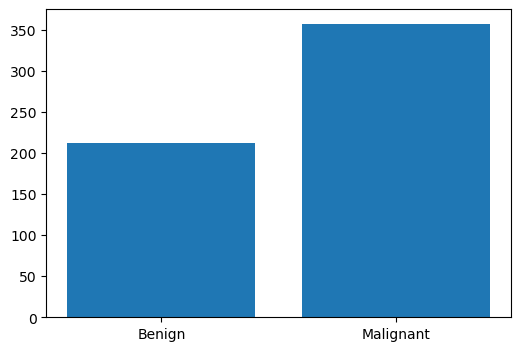

In [8]:
class_names = ["Malignant", "Benign"]
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(data_df["target"].value_counts().index, data_df["target"].value_counts().values)

ax.set_xticks(data_df['target'].value_counts().index)
ax.set_xticklabels(class_names)

In [9]:
features = data_df.drop("target", axis=1)
labels = data_df["target"]
features.shape, labels.shape

((569, 30), (569,))

In [10]:
X_train, X_test, y_train, y_test = train_test_split(features, labels, 
                                                    test_size=TEST_SIZE, 
                                                    stratify=labels,
                                                    random_state=RANDOM_STATE)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((455, 30), (455,), (114, 30), (114,))

In [11]:
# Like if else block
assert(X_train.isin([0,1]).all().all()), 'Features must be binary'

In [3]:
# assert(X_train.isin([0,2]).all().all()), 'Features must be binary'

In [13]:
X_train['total'] = X_train.astype(np.int16).sum(axis=1)
X_train['target'] = y_train

X_train.sort_values('total', inplace=True)
X_train.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,total,target
0,0,0,0,0,0,0,0,0,0,1,...,0,0,1,1,0,0,1,1,12,0
2,0,1,0,0,0,0,0,0,0,1,...,0,1,0,1,1,0,1,1,13,0
1,0,1,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,13,0
7,0,1,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,15,0
6,0,0,0,0,1,0,0,0,1,1,...,0,0,0,0,0,0,1,1,15,0


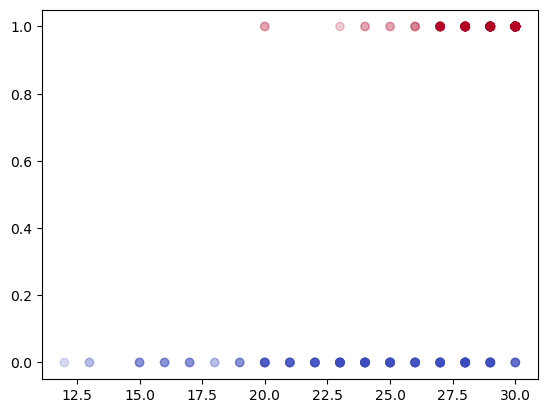

In [14]:
plt.scatter(X_train['total'], X_train['target'], c = X_train['target'], 
            cmap = 'coolwarm', alpha=0.2)

In [ ]:
accuracy = {}

for b in range(X_train.shape[1]):
    X_train['pred'] = X_train['total'] >= b 
    accuracy[b] = accuracy_score(y_true=X_train['target'], 
                                 y_pred=X_train['pred'])   # No matter which values assigned to y_true & y_pred 
    
accuracy

In [16]:
best_b = max(accuracy, key=accuracy.get)
best_b

27

## test data

In [ ]:

X_test['total']=X_test.astype(np.int16).sum(axis=1)# creating 'total' column
X_test['target']=y_test # adding back the labels

In [ ]:
X_test['pred']= X_test['total']>=best_b # making predictions using best b
accuracy_score(X_test['pred'],X_test['target'])